# Confusion Matrix

Suppose we have some tabular data and each observation is labeled either a 0 or 1. Our goal is to create a model and predict whether new data will be labelled a 0 or a 1.

**True Positive (TP)**: An outcome that is labeled 1 and in reality is a 1

**False Positive (FP)**: An outcome that labeled 1 and in reality is a 0

**True Negative (TN)**: An outcome that is labeled 0 and in reality is a 0

**False Negative (FN)**: An outcome that is labeled 0 and in reality is a 1

**Accuracy**: (TP + TN) / (TP + FP + TN + FN)

**Precision**: TP / (TP + FP), a measure of quality

**Recall**: TP / (TP + FN), a measure of quantity

### Type I and Type II Errors 

https://towardsdatascience.com/statistics-for-data-scientists-f2456d26c5a5

Type I Error means rejecting the True null hypothesis and accepting the alternate hypothesis. It is a false positive. A smoke detector detecting smoke when there is no smoke.
Type II Error means accepting the null hypothesis when an alternate hypothesis is true. It is a false negative. When fire alarm fails to detect fire.

### Alpha and Beta Level

Alpha level is also known as the significance level, α. It is the probability of making the wrong decision,i.e., rejecting the null hypothesis when it is true. Low alpha levels mean that we need strong evidence to be able to reject the null hypothesis. This means that alpha level of 1% requires more statistical evidence than 5%.

Why is 0.05 (5%) used as significance level so commonly?

The smaller the alpha level, the little is the chance to reject True Null hypothesis. And, also the smaller is the chance to reject the False null hypothesis, because of the tiny area. The more you try to avoid Type I Error, the more you are likely to make a Type II Error.

A confidence level is 1 - α, which means accepting the null hypothesis when it is True.
Beta level means the probability of making a Type II Error, i.e., rejecting the Alternate hypothesis when it is True.

### Confustion Matrix

In the field of machine learning and specifically the problem of statistical classification, a confusion matrix, also known as an error matrix, is a specific table layout that allows visualization of the performance of an algorithm, typically a supervised learning one (in unsupervised learning it is usually called a matching matrix)... It is a special kind of contingency table, with two dimensions ("actual" and "predicted"), and identical sets of "classes" in both dimensions (each combination of dimension and class is a variable in the contingency table). They provide our True Negatives, False Positives, False Negatives, and True Positives, from which we derive Accuracy, Precision, and Recall.

https://en.wikipedia.org/wiki/Confusion_matrix

**Note**: Because of the of the output sklearn provides, we will structure our table different from what Wikipedia says.

Confused? Please be aware of the distinction. In this course we will be using the sklearn matrix. There is a way to change the rows and columns to match Wikipedia's matrix by adding labels: confusion_matrix(y_test, predictions, labels=\[1, 0\]).

In [22]:
# Create dataset
n = 1000 # number of observations
f = 2 # number of features
inform = 2 # number of meaningful features
features, binary_class = make_classification(n_samples=n, n_features=f,  
                                             n_informative=inform, n_redundant=0, 
                                             n_clusters_per_class=1, random_state=13)

# Create a dataframe of the features and add the binary class (label, output)
df = pd.DataFrame(features)
df.columns = ['Feature_1', 'Feature_2']
df['Target'] = binary_class
df.head()

,Feature_1,Feature_2,Target
0,-1.355723,0.932216,0
1,-1.448966,0.628289,0
2,-0.259349,-0.792658,0
3,0.815272,-0.205096,1
4,1.430197,1.342170,1


In [23]:
# X_train, X_test split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Target', axis=1), df['Target'], test_size=0.20)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [24]:
# Create model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear')
model.fit(X_train,y_train)
predictions = model.predict(X_test)

**The Solver (liblinear)**: Solvers are used to minimize the loss function which in turn provides our best coefficients. Please see the documentation to learn about the five different solvers.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


In [25]:
# View confusion matrix
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report

tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
print('Confusion Matrix')
print(confusion_matrix(y_test, predictions))
print()
print('Here is what the numbers represent from the sklLearn output')
print('''
                 predicted
                   |  0  |  1
           --------------------  
           class 0 | TN  |  FP      
  actual   --------------------
           class 1 | FN  |  TP
''')
print()
print('Here is what the numbers represent from the Wikipedia article')
print('''
                 actual
                   |  1  |  0
           --------------------  
           class 1 | TP  |  FP      
predicted  --------------------
           class 0 | FN  |  TN
''')

Confusion Matrix
[[72 18]
 [13 97]]

Here is what the numbers represent from the sklLearn output

                 predicted
                   |  0  |  1
           --------------------  
           class 0 | TN  |  FP      
  actual   --------------------
           class 1 | FN  |  TP


Here is what the numbers represent from the Wikipedia article

                 actual
                   |  1  |  0
           --------------------  
           class 1 | TP  |  FP      
predicted  --------------------
           class 0 | FN  |  TN



In [26]:
# Compare with crosstab
pd.crosstab(y_test, predictions, rownames=['Actual'], colnames=['Predicted'],margins=True)

Predicted,0,1,All
Actual,,,
0,72,18,90
1,13,97,110
All,85,115,200


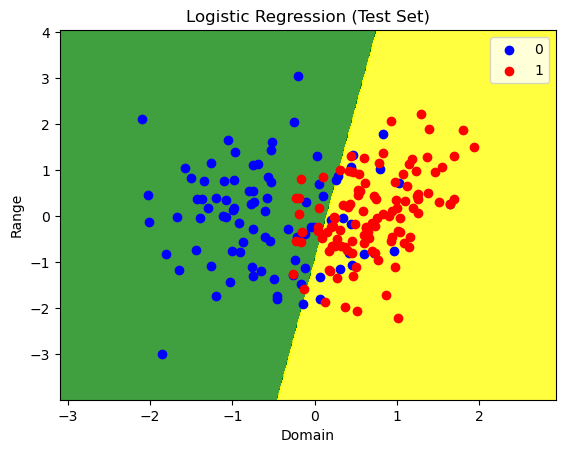

In [27]:
# review our plot
from matplotlib.colors import ListedColormap

X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))

plt.contourf(X1, X2, model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('green', 'yellow')))

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color = ListedColormap(('blue', 'red'))(i), label = j)

plt.title('Logistic Regression (Test Set)')
plt.xlabel('Domain')
plt.ylabel('Range')
plt.legend()
plt.show()

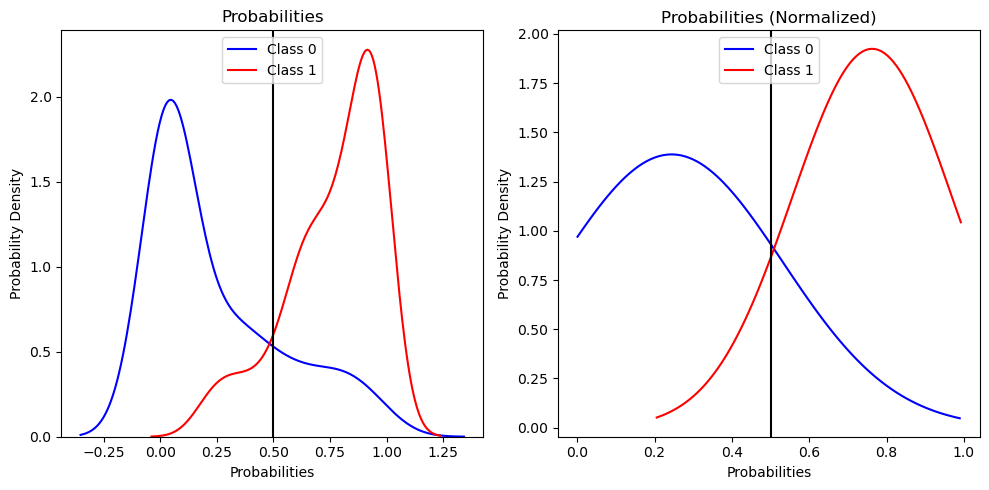

In [28]:
# Compare KDE plots for probabilities and normed probabilities
import seaborn as sns
import scipy

import warnings
warnings.filterwarnings('ignore')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))

probs=model.predict_proba(X_test)[:,1]
sns.kdeplot(probs[y_test==0], shade=False, color='blue', label='Class 0', ax=ax1);
sns.kdeplot(probs[y_test==1], shade=False, color='red', label='Class 1', ax=ax1);
ax1.axvline(x=.5, color='black')
ax1.set_title('Probabilities')
ax1.set(xlabel='Probabilities', ylabel='Probability Density')

mean = probs[y_test==0].mean() 
std = probs[y_test==0].std()
x = np.linspace(probs[y_test==0].min(), probs[y_test==0].max(), 100)
y = scipy.stats.norm.pdf(x,mean,std)
ax2.plot(x, y, color='blue', label='Class 0')

mean = probs[y_test==1].mean() 
std = probs[y_test==1].std()
x = np.linspace(probs[y_test==1].min(), probs[y_test==1].max(), 100)
y = scipy.stats.norm.pdf(x,mean,std)
ax2.plot(x, y, color='red', label='Class 1')

x_threshold = 0.5
ax2.axvline(x=x_threshold,color='black')

ax2.set_title('Probabilities (Normalized)')
ax2.set(xlabel='Probabilities', ylabel='Probability Density')

ax1.legend(loc='upper center')
ax2.legend(loc='upper center')
plt.tight_layout()
plt.show()

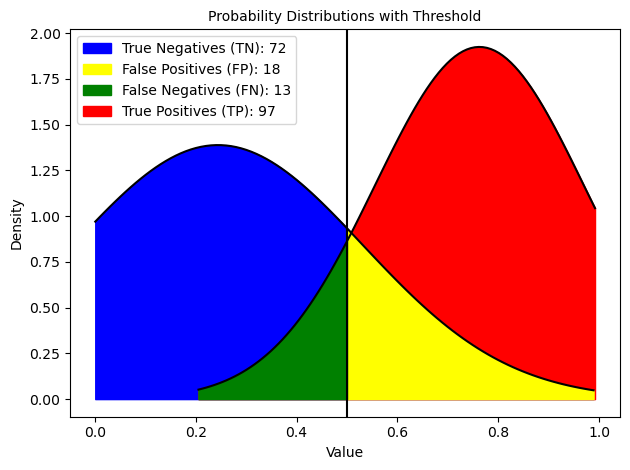

In [29]:
# visualize TN, FN, FP, TP
import math
import matplotlib.patches as mpatches

x_threshold = 0.5
tn, fp, fn, tp = confusion_matrix(y_test,predictions).ravel()

mean_0 = probs[y_test==0].mean() 
std_0 = probs[y_test==0].std()
x_0 = np.linspace(probs[y_test==0].min(), probs[y_test==0].max(), 100)
y_0 = scipy.stats.norm.pdf(x_0,mean_0,std_0)

mean_1 = probs[y_test==1].mean() 
std_1 = probs[y_test==1].std()
x_1 = np.linspace(probs[y_test==1].min(), probs[y_test==1].max(), 100)
y_1 = scipy.stats.norm.pdf(x_1,mean_1,std_1)

plt.plot(x_0, y_0, color='black')
plt.fill_between(x_0, y_0, color='blue', alpha=1)

plt.plot(x,y, color='black')
plt.fill_between(x_1, y_1, color='red', alpha=1)

ptx_0 = np.linspace(x_threshold, probs[y_test==0].max(), 100)
pty_0 = scipy.stats.norm.pdf(ptx_0,mean_0,std_0)
plt.fill_between(ptx_0, pty_0, color='yellow', alpha=1)

ptx_1 = np.linspace(probs[y_test==1].min(), x_threshold, 100)
pty_1 = scipy.stats.norm.pdf(ptx_1,mean_1,std_1)
plt.fill_between(ptx_1, pty_1, color='green', alpha=1)

tn_patch = mpatches.Patch(color='blue', label='True Negatives (TN): ' + str(tn))
fp_patch = mpatches.Patch(color='yellow', label='False Positives (FP): ' + str(fp))
fn_patch = mpatches.Patch(color='green', label='False Negatives (FN): ' + str(fn))
tp_patch = mpatches.Patch(color='red', label='True Positives (TP): ' + str(tp))
plt.legend(handles=[tn_patch,fp_patch,fn_patch,tp_patch], loc=2)

plt.title('Probability Distributions with Threshold',fontsize=10)
plt.axvline(x=x_threshold,color='black')
plt.xlabel('Value')
plt.ylabel('Density')

plt.tight_layout()

### Underfitting and Overfitting

In statistics, overfitting is "the production of an analysis that corresponds too closely or exactly to a particular set of data, and may therefore fail to fit additional data or predict future observations reliably". An overfitted model is a statistical model that contains more parameters than can be justified by the data.

<img src='https://docs.aws.amazon.com/images/machine-learning/latest/dg/images/mlconcepts_image5.png' alt='underfitting overfitting' />

https://docs.aws.amazon.com/machine-learning/latest/dg/model-fit-underfitting-vs-overfitting.html

If you're overfitting, or you are getting great training scores and poor  test scores, you might be overfitting so try removing the lesser performing features. The model is just memorizing the training data.

Underfitting occurs when a statistical model cannot adequately capture the underlying structure of the data. An under-fitted model is a model where some parameters or terms that would appear in a correctly specified model are missing.[2] Under-fitting would occur, for example, when fitting a linear model to non-linear data. Such a model will tend to have poor predictive performance.

If you're underfitting, or you are getting poor training scores and test scores, you might be underfitting so try adding more data or more features.

https://en.wikipedia.org/wiki/Overfitting

### Bias Variance Tradeoff

In statistics and machine learning, the bias–variance tradeoff is the property of a model that the variance of the parameter estimates across samples can be reduced by increasing the bias in the estimated parameters. The bias–variance dilemma or bias–variance problem is the conflict in trying to simultaneously minimize these two sources of error that prevent supervised learning algorithms from generalizing beyond their training set.

https://en.wikipedia.org/wiki/Bias%E2%80%93variance_tradeoff

Please become familiar with this image:

<img src='https://www.kdnuggets.com/wp-content/uploads/bias-and-variance.jpg' alt='bias variance tradeoff' />

Please read the article responsible for the image:

https://www.kdnuggets.com/2016/08/bias-variance-tradeoff-overview.html

#### A Formula

$E[(\hat{y} - y)^2] = E[(\hat{y} - E[\hat{y})^2] + (E[\hat{y}] - y)^2$
<br />MSE = Variance + Bias^2
* where y = given y, (ground truth)
* $\hat{y}$ = prediction
* $E[\hat{y}]$ = expected value or average of predictions
* error = $\frac{fp + fn}{total}$
* Bias = error in training
* Variance = range of predictions, how much an estimate of the target function will change if different data was is

<table width='50%' style='margin-right: 100%'>
    <tr>
        <td>Training Error</td>
        <td>1%</td>
        <td>15%</td>
        <td>16%</td>
        <td>1%</td>
    </tr>
    <tr>
        <td>Testing Error</td>
        <td>15%</td>
        <td>16%</td>
        <td>33%</td>
        <td>1%</td>
    </tr>
    <tr>
        <td></td>
        <td>lo bias</td>
        <td>hi bias</td>
        <td>hi bias</td>
        <td>lo bias</td>
    </tr>
    <tr>
        <td></td>
        <td>hi var</td>
        <td>lo var</td>
        <td>hi var</td>
        <td>lo var</td>
    </tr>
</table>

https://www.mastersindatascience.org/learning/difference-between-bias-and-variance/

### The Classification Report for Imbalanced Data Sets

Both the titanic and cancer datasets weren't as balanced as they could be but to appreciate the implications of an imbalanced dataset, consider a fraudualent credit card dataset where there may be a 1 (for fraudulent activity) per 1000 0s of normal activity. We wouldn't need to build a predictive model to make correct predictions 99% of the time. The data itself lets us do that. We need metrics that tell us that the model we build is learning about the relevant data and that it predicts what it is suppose to predict. This gets back to our Precision Recall Tradeoff. 

**Precision**: The sum of observations correctly classified as positive out of the total observations classified as positive. From the formula, tp / (tp + fp), we can see we want to mimimize fp (false positives), or type I errors, which is sounding an alarm when there is no fire.

**Recall**: The sum of observations correctly classified as positive out of the total actual positives. From the forumula, tp / (tp + fn), we can see we want to minimize fn (false negatives), or type II errors, which is not sounding an alarm when there is a fire.

In [30]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[72 18]
 [13 97]]
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        90
           1       0.84      0.88      0.86       110

    accuracy                           0.84       200
   macro avg       0.85      0.84      0.84       200
weighted avg       0.85      0.84      0.84       200



* precision 0: 114 / 137
* precision 1: 66 / 86
* recall 0: 114 / 134
* recall 1: 66 / 89

We know about accuracy, precision, and recall and we've talked about f1-score as being the harmonic mean of precision and recall (f1 score = 2 * (precision * recall) / (precision + recall)). 

* support: the number of observations labeled 0 or 1 (remember the pie chart we made of the target?)
* macro avg: the average between the two classes (e.g. (prec 0 + prec 1) / 2
* weighted avg: the average between the two classes taking into account the number of their observations (e.g. ((prec0 * score0) + (prec 1 * score1)) / total)

A classification report provides a little more information by providing metrics for each class. For example, for class 0, our recall is higher than our precision, which tells us that there are fewer false negatives than false positives in class 0.

In [31]:
import numpy as np

print((.83 + .77) / 2)
wgt_exmpl = ((.83 * 134) + (.77 * 89)) / (134 + 89)
print(np.round(wgt_exmpl, 2))

0.8
0.81


### Precision Recall Tradeoff

In pattern recognition, information retrieval and classification (machine learning), precision (also called positive predictive value) is the fraction of relevant instances among the retrieved instances, while recall (also known as sensitivity) is the fraction of relevant instances that were retrieved. Both precision and recall are therefore based on relevance... Accuracy can be a misleading metric for imbalanced data sets. Consider a sample with 95 negative and 5 positive values. Classifying all values as negative in this case gives 0.95 accuracy score.

https://en.wikipedia.org/wiki/Precision_and_recall

In cases of imbalanced data, precision, recall, and f1 score become useful metrics. Precision tells us the proportion of data that was predicted was actually predicted correctly. Recall, also known as the True Positive Rate, is the probability that an actual positive will be predicted to be positive.

Precision (also called positive predictive value) is the fraction of relevant instances among the retrieved instances, while recall (also known as sensitivity) is the fraction of relevant instances that were retrieved. Both precision and recall are therefore based on relevance.

https://en.wikipedia.org/wiki/Precision_and_recall 

<img src='https://miro.medium.com/v2/resize:fit:640/format:webp/1*GM10sFuFBAbhwBt2scuP1g.png' alt='precision recall tradeoff' />

https://datascience-george.medium.com/the-precision-recall-trade-off-aa295faba140

The following is a visualization of our true negatives, false positives, false negatives, and true positives from the data set generated with make_classification.

In [32]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
print('Confusion Matrix')
print()
print(f'''
           survived predicted
                   |  0   |  1     
           -----------------------  -----------------------------------------
           no      | {tn}  |  {fp}     fpr (type I error)  | tnr  
  actual   -----------------------  -----------------------------------------
           yes     | {fn}   |  {tp}     tpr (recall)        | fnr (type II error)

                    for   | precision
           ----------------------------
                    npv   | fdr

''')

Confusion Matrix


           survived predicted
                   |  0   |  1     
           -----------------------  -----------------------------------------
           no      | 72  |  18     fpr (type I error)  | tnr  
  actual   -----------------------  -----------------------------------------
           yes     | 13   |  97     tpr (recall)        | fnr (type II error)

                    for   | precision
           ----------------------------
                    npv   | fdr




### Metrics

* tn = pred 0 actual 0
* fp = pred 1 actual 0
* fn = pred 0 actual 1
* tp = pred 1 actual 1
* acc(uracy) = $\frac{tn + tp}{total}$
* error = $\frac{fp + fn}{total}$
* prev(alence) = $\frac{fn + tp}{total}$
* queue = $\frac{fp + tp}{total}$
* tpr = $\frac{tp}{tp + fn}$
    * true positive rate
    * recall
    * sensitivity
    * prob of detection
    * 1 - fnr
* fnr = $\frac{fn}{tp + fn}$
    * false negative rate
    * type II error
    * 1 - tpr
* tnr = $\frac{tn}{tn + fp}$
    * true negative rate
    * specificity
    * 1 - fpr
* fpr = $\frac{fp}{tn + fp}$
    * false positive rate
    * type I error
    * fall out
    * prob of false claim
    * 1 - tnr
* ppv = $\frac{tp}{tp + fp}$
    * positive predicted value
    * precision
    * 1 - fdr
* fdr = $\frac{fp}{tp + fp}$
    * false discovery rate
    * 1 - ppv
* npv = $\frac{tn}{tn + fn}$
    * negative predicted value
    * 1 - for
* for = $\frac{fn}{tn + fn}$
    * false omission rate
    * 1 - npv
* liklihood ratio+ (lr+) = $\frac{tpr}{fpr}$
    * roc
* liklihood ratio- (lr-) = $\frac{fnr}{tnr}$
* diagnostic odds ratio = $\frac{lr+}{lr-}$
* f1 score = 2 * $\frac{precision-recall}{precision+recall}$
* Youden's J = sensitivity + specificity - 1 = tpr - fpr
* Matthew's Correlation Coefficient = $\frac{(tp*tn)-(fp*tp)}{\sqrt{(tp+fp)(tp+fn)(tn+fp)(tn+fn)}}$
  